In [1]:
import os
os.listdir('/kaggle/input/datasets/nikhilshettyvsn')

['heart-disease-prediction1', 'heart-disease']

In [2]:
os.listdir('/kaggle/input/datasets/nikhilshettyvsn/heart-disease')

['heart-csv.ipynb']

In [3]:
os.listdir('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1')

['cleaned_data.csv',
 'app.py',
 'pyvenv.cfg',
 'requirements.txt',
 'LOG_model.jobliib',
 'EDA_analysis (1).ipynb',
 'heart-disease-names copy.names',
 'heart.csv']

In [4]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    int64  
 3   cp          303 non-null    int64  
 4   trestbps    303 non-null    int64  
 5   chol        303 non-null    int64  
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     303 non-null    int64  
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 35.6 KB


,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,151.000000,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,87.612784,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,0.000000,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.500000,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,151.000000,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,226.500000,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,302.000000,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.columns

Index(['Unnamed: 0', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.dtypes

Unnamed: 0      int64
age             int64
sex             int64
cp              int64
trestbps        int64
chol            int64
fbs             int64
restecg         int64
thalach         int64
exang           int64
oldpeak       float64
slope           int64
ca              int64
thal            int64
target          int64
dtype: object

In [8]:
df.isnull().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

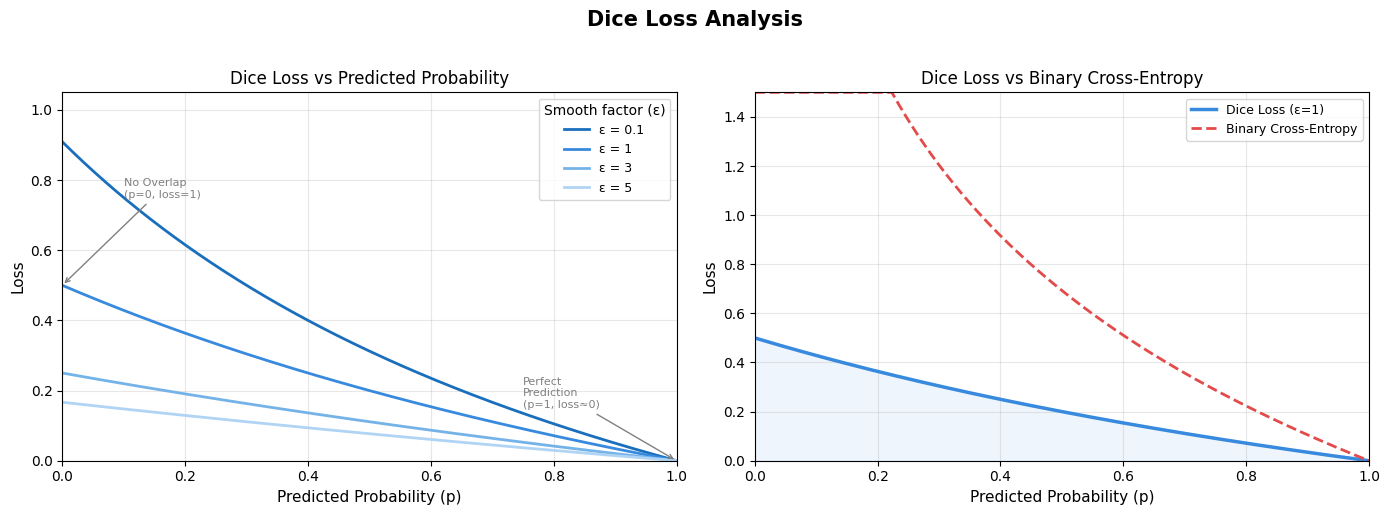

  Dice Loss Key Values (ε = 1)
  p = 0.00  →  loss = 0.5000
  p = 0.10  →  loss = 0.4286
  p = 0.25  →  loss = 0.3333
  p = 0.50  →  loss = 0.2000
  p = 0.75  →  loss = 0.0909
  p = 0.90  →  loss = 0.0345
  p = 1.00  →  loss = 0.0000


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Dice Loss formula ──────────────────────────────────────────────────────────
def dice_loss(p, smooth=1):
    return 1 - (2 * p + smooth) / (p + 1 + smooth)

# Binary Cross-Entropy for reference
def bce_loss(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.log(p)

# ── Data ───────────────────────────────────────────────────────────────────────
p = np.linspace(0, 1, 500)

smooth_values = [0.1, 1, 3, 5]
colors = ['#1a6fbd', '#378ADD', '#74B3E8', '#B0D4F4']

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dice Loss Analysis', fontsize=15, fontweight='bold', y=1.02)

# ── Plot 1: Dice Loss with different smooth values ─────────────────────────────
ax1 = axes[0]
for smooth, color in zip(smooth_values, colors):
    loss = dice_loss(p, smooth)
    ax1.plot(p, loss, label=f'ε = {smooth}', color=color, linewidth=2)

ax1.set_title('Dice Loss vs Predicted Probability', fontsize=12)
ax1.set_xlabel('Predicted Probability (p)', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend(title='Smooth factor (ε)', fontsize=9)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Annotate key points
ax1.annotate('Perfect\nPrediction\n(p=1, loss≈0)',
             xy=(1, dice_loss(1, 1)), xytext=(0.75, 0.15),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=8, color='gray')

ax1.annotate('No Overlap\n(p=0, loss=1)',
             xy=(0, dice_loss(0, 1)), xytext=(0.1, 0.75),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=8, color='gray')

# ── Plot 2: Dice Loss vs BCE comparison ────────────────────────────────────────
ax2 = axes[1]

dice = dice_loss(p, smooth=1)
bce  = bce_loss(p)
bce  = np.clip(bce, 0, 1.5)   # clip for visual clarity

ax2.plot(p, dice, label='Dice Loss (ε=1)', color='#378ADD', linewidth=2.5)
ax2.plot(p, bce,  label='Binary Cross-Entropy', color='#E24B4A',
         linewidth=2, linestyle='--')
ax2.fill_between(p, dice, alpha=0.08, color='#378ADD')

ax2.set_title('Dice Loss vs Binary Cross-Entropy', fontsize=12)
ax2.set_xlabel('Predicted Probability (p)', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dice_loss_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print key values ───────────────────────────────────────────────────────────
print("=" * 40)
print("  Dice Loss Key Values (ε = 1)")
print("=" * 40)
for prob in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
    print(f"  p = {prob:.2f}  →  loss = {dice_loss(prob, 1):.4f}")
print("=" * 40)

In [10]:
import os

print(os.listdir())

['.virtual_documents', 'dice_loss_graph.png']


In [11]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/cleaned_data.csv
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/app.py
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/pyvenv.cfg
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/requirements.txt
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/LOG_model.jobliib
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/EDA_analysis (1).ipynb
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart-disease-names copy.names
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv
/kaggle/input/datasets/nikhilshettyvsn/heart-disease/heart-csv.ipynb
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__results__.html
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__notebook__.ipynb
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__output__.json
/kaggle/input/notebooks/kedar11/heart-disease-dataset/custom.cs

In [12]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/cleaned_data.csv
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/app.py
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/pyvenv.cfg
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/requirements.txt
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/LOG_model.jobliib
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/EDA_analysis (1).ipynb
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart-disease-names copy.names
/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv
/kaggle/input/datasets/nikhilshettyvsn/heart-disease/heart-csv.ipynb
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__results__.html
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__notebook__.ipynb
/kaggle/input/notebooks/kedar11/heart-disease-dataset/__output__.json
/kaggle/input/notebooks/kedar11/heart-disease-dataset/custom.cs

In [13]:
# ── 2. LOAD DATASET ──────────────────────────────────────────

df = pd.read_csv(
    "/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv"
)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (303, 15)
   Unnamed: 0  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
0           0   63    1   3       145   233    1        0      150      0   
1           1   37    1   2       130   250    0        1      187      0   
2           2   41    0   1       130   204    0        0      172      0   
3           3   56    1   1       120   236    0        1      178      0   
4           4   57    0   0       120   354    0        1      163      1   

   oldpeak  slope  ca  thal  target  
0      2.3      0   0     1       1  
1      3.5      0   0     2       1  
2      1.4      2   0     2       1  
3      0.8      2   0     2       1  
4      0.6      2   0     2       1  


DATASET LOADED SUCCESSFULLY
Dataset Shape: (303, 15)

First 5 Rows:

   Unnamed: 0  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
0           0   63    1   3       145   233    1        0      150      0   
1           1   37    1   2       130   250    0        1      187      0   
2           2   41    0   1       130   204    0        0      172      0   
3           3   56    1   1       120   236    0        1      178      0   
4           4   57    0   0       120   354    0        1      163      1   

   oldpeak  slope  ca  thal  target  
0      2.3      0   0     1       1  
1      3.5      0   0     2       1  
2      1.4      2   0     2       1  
3      0.8      2   0     2       1  
4      0.6      2   0     2       1  

Training Shape : (242, 14)
Testing Shape  : (61, 14)

MODEL TRAINED SUCCESSFULLY!

MODEL EVALUATION REPORT
Accuracy        : 1.0000
Precision       : 1.0000
Recall          : 1.0000
F1 Score        : 1.0000
ROC-AUC         : 1.0000
MCC    

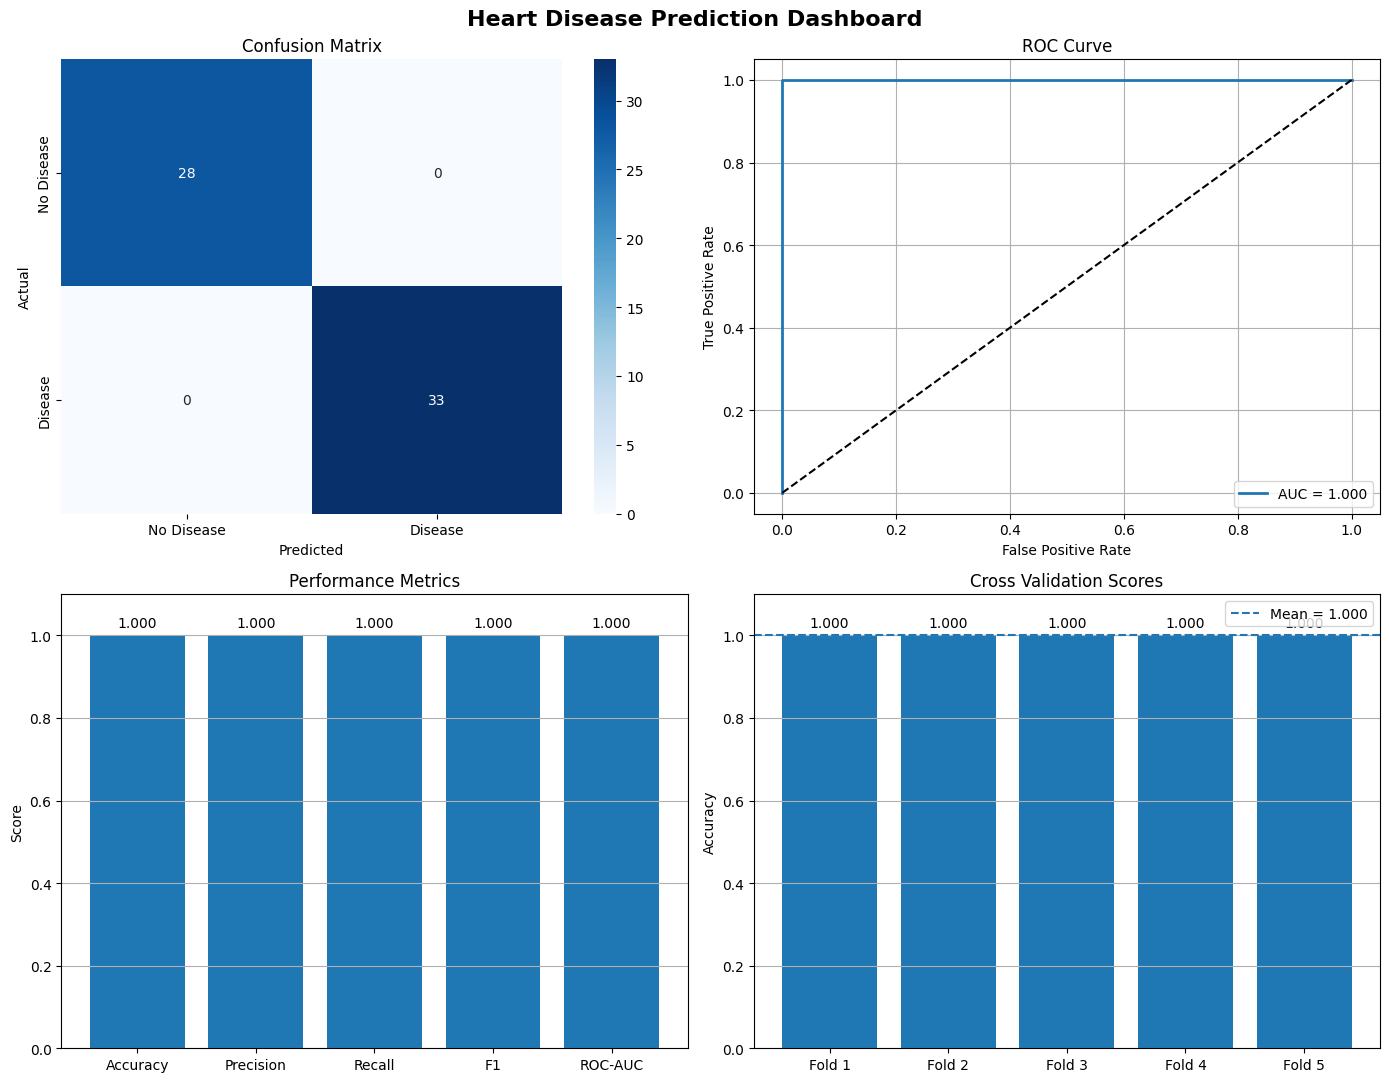


Dashboard Saved Successfully: model_evaluation.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# HEART DISEASE PREDICTION - FULL MODEL TRAINING + EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. IMPORT LIBRARIES ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss
)

# ── 2. LOAD DATASET ──────────────────────────────────────────────────────────
df = pd.read_csv(
    "/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv"
)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n")
print(df.head())

# ── 3. FEATURES & TARGET ─────────────────────────────────────────────────────
# Target column = target
X = df.drop("target", axis=1)
y = df["target"]

# ── 4. TRAIN TEST SPLIT ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ── 5. BUILD MODEL ───────────────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# ── 6. TRAIN MODEL ───────────────────────────────────────────────────────────
model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY!")

# ── 7. PREDICTIONS ───────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ══════════════════════════════════════════════════════════════════════════════
# 8. PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)
mcc       = matthews_corrcoef(y_test, y_pred)
logloss   = log_loss(y_test, y_pred_proba)

print("\n" + "=" * 60)
print("MODEL EVALUATION REPORT")
print("=" * 60)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")
print(f"MCC             : {mcc:.4f}")
print(f"Log Loss        : {logloss:.4f}")

print("=" * 60)

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Disease", "Disease"]
    )
)

# ══════════════════════════════════════════════════════════════════════════════
# 9. OVERFITTING CHECK
# ══════════════════════════════════════════════════════════════════════════════
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)

gap = train_acc - test_acc

print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)

print(f"Train Accuracy  : {train_acc:.4f}")
print(f"Test Accuracy   : {test_acc:.4f}")
print(f"Gap             : {gap:.4f}")

if gap < 0.05:
    print("Status          : GOOD — Model Generalizes Well")
elif gap < 0.10:
    print("Status          : WARNING — Slight Overfitting")
else:
    print("Status          : BAD — Severe Overfitting")

print("=" * 60)

# ══════════════════════════════════════════════════════════════════════════════
# 10. CROSS VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("\nCROSS VALIDATION RESULTS")
print("-" * 40)

print("Scores  :", cv_scores.round(4))
print("Mean    :", round(cv_scores.mean(), 4))
print("Std Dev :", round(cv_scores.std(), 4))

# ══════════════════════════════════════════════════════════════════════════════
# 11. VISUALIZATION DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

fig.suptitle(
    'Heart Disease Prediction Dashboard',
    fontsize=16,
    fontweight='bold'
)

# ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0, 0],
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# ── ROC CURVE ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.3f}'
)

axes[0, 1].plot([0, 1], [0, 1], 'k--')

axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ── METRICS BAR CHART ────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

bars = axes[1, 0].bar(metrics, values)

axes[1, 0].set_ylim(0, 1.1)
axes[1, 0].set_title('Performance Metrics')
axes[1, 0].set_ylabel('Score')

for bar, val in zip(bars, values):
    axes[1, 0].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.02,
        f'{val:.3f}',
        ha='center'
    )

axes[1, 0].grid(True, axis='y')

# ── CROSS VALIDATION GRAPH ───────────────────────────────────────────────────
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]

axes[1, 1].bar(folds, cv_scores)

axes[1, 1].axhline(
    y=cv_scores.mean(),
    linestyle='--',
    label=f'Mean = {cv_scores.mean():.3f}'
)

axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_title('Cross Validation Scores')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

for i, val in enumerate(cv_scores):
    axes[1, 1].text(
        i,
        val + 0.02,
        f'{val:.3f}',
        ha='center'
    )

axes[1, 1].grid(True, axis='y')

# ── SAVE & SHOW ──────────────────────────────────────────────────────────────
plt.tight_layout()

plt.savefig(
    'model_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\nDashboard Saved Successfully: model_evaluation.png")

In [15]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import os

# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv')

print("✅ Data Loaded")
print(df.head())

# ==========================================
# 3. CHECK DATA
# ==========================================
print(df.info())
print(df.describe())

# ==========================================
# 4. HANDLE MISSING VALUES
# ==========================================
df = df.fillna(df.mean())

# ==========================================
# 5. HANDLE CATEGORICAL DATA (if any)
# ==========================================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ==========================================
# 6. SPLIT FEATURES & TARGET
# ==========================================
# ⚠️ change 'target' if your column name is different
X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# 7. TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 8. FEATURE SCALING
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 9. TRAIN MODEL
# ==========================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model Trained")

# ==========================================
# 10. PREDICTIONS
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 11. EVALUATION
# ==========================================
print("\n📊 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 12. OVERFITTING CHECK
# ==========================================
print("\nTrain Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

# ==========================================
# 13. SAVE MODEL + SCALER
# ==========================================
os.makedirs('/kaggle/working/heart_model', exist_ok=True)

with open('/kaggle/working/heart_model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('/kaggle/working/heart_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ Model saved at /kaggle/working/heart_model/model.pkl")
print("✅ Scaler saved at /kaggle/working/heart_model/scaler.pkl")

# ==========================================
# 14. TEST SAVED MODEL
# ==========================================
with open('/kaggle/working/heart_model/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('/kaggle/working/heart_model/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

sample = X_test[:1]
original_pred = model.predict(sample)[0]
loaded_pred = loaded_model.predict(sample)[0]

print("\n✅ Original Prediction:", original_pred)
print("✅ Loaded Prediction :", loaded_pred)
print("✅ Match:", original_pred == loaded_pred)

✅ Data Loaded
   Unnamed: 0  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
0           0   63    1   3       145   233    1        0      150      0   
1           1   37    1   2       130   250    0        1      187      0   
2           2   41    0   1       130   204    0        0      172      0   
3           3   56    1   1       120   236    0        1      178      0   
4           4   57    0   0       120   354    0        1      163      1   

   oldpeak  slope  ca  thal  target  
0      2.3      0   0     1       1  
1      3.5      0   0     2       1  
2      1.4      2   0     2       1  
3      0.8      2   0     2       1  
4      0.6      2   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-n

In [16]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 2. DEFINE DICE LOSS
# ==========================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)  # convert logits → probabilities
        
        y_pred = y_pred.view(-1)
        y_true = y_true.view(-1)

        intersection = (y_pred * y_true).sum()

        dice = (2. * intersection + self.smooth) / \
               (y_pred.sum() + y_true.sum() + self.smooth)

        return 1 - dice

# ==========================================
# 3. SIMPLE MODEL (DUMMY)
# ==========================================
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

# ==========================================
# 4. CREATE MODEL, LOSS, OPTIMIZER
# ==========================================
model = SimpleModel()
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 5. DUMMY DATA (SIMULATION)
# ==========================================
X = torch.randn(100, 10)              # 100 samples, 10 features
y = torch.randint(0, 2, (100, 1)).float()  # binary labels

# ==========================================
# 6. TRAINING LOOP
# ==========================================
epochs = 10

for epoch in range(epochs):
    model.train()

    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ==========================================
# 7. TEST PREDICTION
# ==========================================
model.eval()
with torch.no_grad():
    test_sample = torch.randn(1, 10)
    prediction = torch.sigmoid(model(test_sample))
    print("\nPrediction Probability:", prediction.item())

    if prediction.item() > 0.5:
        print("Class: 1 (Positive)")
    else:
        print("Class: 0 (Negative)")

Epoch 1/10, Loss: 0.4640
Epoch 2/10, Loss: 0.4637
Epoch 3/10, Loss: 0.4635
Epoch 4/10, Loss: 0.4632
Epoch 5/10, Loss: 0.4630
Epoch 6/10, Loss: 0.4627
Epoch 7/10, Loss: 0.4625
Epoch 8/10, Loss: 0.4622
Epoch 9/10, Loss: 0.4619
Epoch 10/10, Loss: 0.4617

Prediction Probability: 0.7275112867355347
Class: 1 (Positive)


Epoch 1, Loss: 0.4790
Epoch 2, Loss: 0.4788
Epoch 3, Loss: 0.4786
Epoch 4, Loss: 0.4784
Epoch 5, Loss: 0.4781
Epoch 6, Loss: 0.4779
Epoch 7, Loss: 0.4777
Epoch 8, Loss: 0.4775
Epoch 9, Loss: 0.4772
Epoch 10, Loss: 0.4770
Epoch 11, Loss: 0.4768
Epoch 12, Loss: 0.4766
Epoch 13, Loss: 0.4763
Epoch 14, Loss: 0.4761
Epoch 15, Loss: 0.4759
Epoch 16, Loss: 0.4757
Epoch 17, Loss: 0.4754
Epoch 18, Loss: 0.4752
Epoch 19, Loss: 0.4750
Epoch 20, Loss: 0.4748


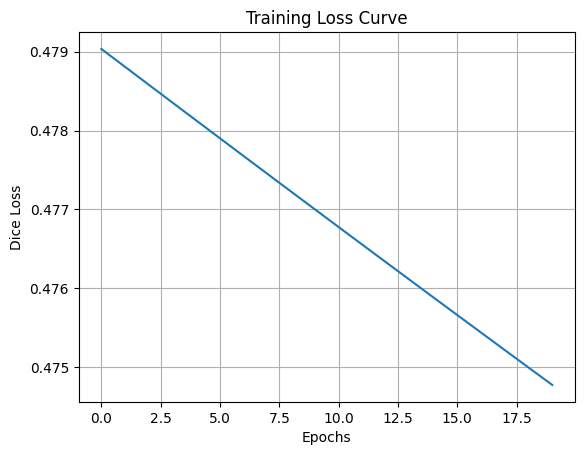

In [17]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 2. DEFINE DICE LOSS
# ==========================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)
        
        y_pred = y_pred.view(-1)
        y_true = y_true.view(-1)

        intersection = (y_pred * y_true).sum()

        dice = (2. * intersection + self.smooth) / \
               (y_pred.sum() + y_true.sum() + self.smooth)

        return 1 - dice

# ==========================================
# 3. MODEL
# ==========================================
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

# ==========================================
# 4. SETUP
# ==========================================
model = SimpleModel()
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 5. DATA
# ==========================================
X = torch.randn(100, 10)
y = torch.randint(0, 2, (100, 1)).float()

# ==========================================
# 6. TRAINING + STORE LOSS
# ==========================================
epochs = 20
losses = []

for epoch in range(epochs):
    model.train()

    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ==========================================
# 7. PLOT GRAPH 📈
# ==========================================
plt.figure()
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Dice Loss")
plt.grid()
plt.show()

In [18]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score
)

# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv')

print("✅ Data Loaded")
print(df.head())

# ==========================================
# 3. PREPROCESSING
# ==========================================
# Handle missing values
df = df.fillna(df.mean())

# Encode categorical (if any)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ==========================================
# 4. SPLIT FEATURES & TARGET
# ==========================================
X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# 5. TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 6. SCALING
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 7. TRAIN MODEL
# ==========================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\n✅ Model Trained")

# ==========================================
# 8. PREDICTIONS
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 9. EVALUATION
# ==========================================

# Accuracy
print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))

# Train vs Test Accuracy
print("\n📊 Train Accuracy:", model.score(X_train, y_train))
print("📊 Test Accuracy :", model.score(X_test, y_test))

# Confusion Matrix
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Precision
print("\n📊 Precision:", precision_score(y_test, y_pred))

# Recall (VERY IMPORTANT)
print("📊 Recall   :", recall_score(y_test, y_pred))

# F1 Score
print("📊 F1 Score :", f1_score(y_test, y_pred))

# Full Report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================================
# 10. SIMPLE INTERPRETATION
# ==========================================
acc = accuracy_score(y_test, y_pred)

if acc > 0.9:
    print("\n🔥 Excellent Model")
elif acc > 0.8:
    print("\n👍 Good Model")
else:
    print("\n⚠️ Needs Improvement")

✅ Data Loaded
   Unnamed: 0  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
0           0   63    1   3       145   233    1        0      150      0   
1           1   37    1   2       130   250    0        1      187      0   
2           2   41    0   1       130   204    0        0      172      0   
3           3   56    1   1       120   236    0        1      178      0   
4           4   57    0   0       120   354    0        1      163      1   

   oldpeak  slope  ca  thal  target  
0      2.3      0   0     1       1  
1      3.5      0   0     2       1  
2      1.4      2   0     2       1  
3      0.8      2   0     2       1  
4      0.6      2   0     2       1  

✅ Model Trained

🎯 Accuracy: 0.9672131147540983

📊 Train Accuracy: 0.987603305785124
📊 Test Accuracy : 0.9672131147540983

📊 Confusion Matrix:
 [[29  0]
 [ 2 30]]

📊 Precision: 1.0
📊 Recall   : 0.9375
📊 F1 Score : 0.967741935483871

📊 Classification Report:

              precision    recall  

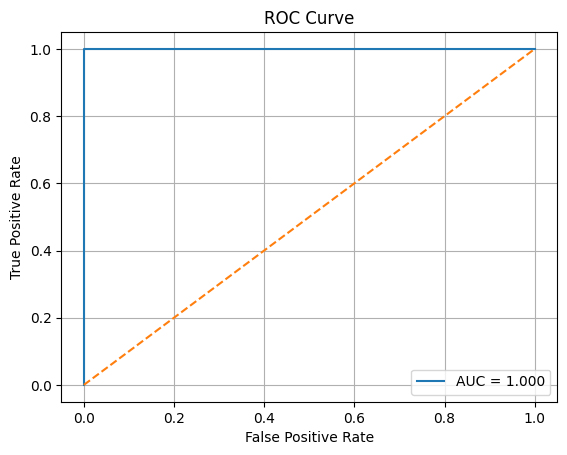

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 1.0



🎯 Accuracy: 0.8524590163934426

📊 Confusion Matrix:
 [[24  5]
 [ 4 28]]

📊 Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



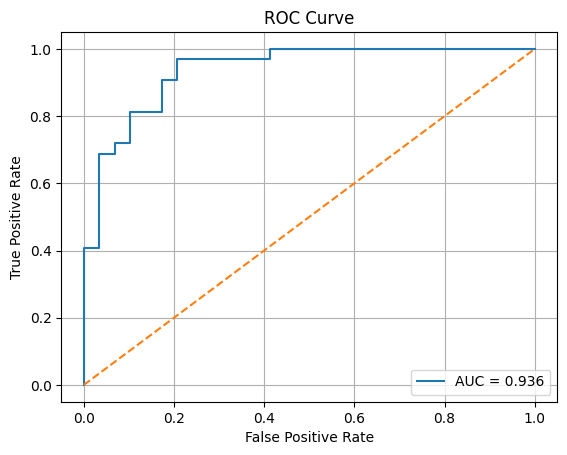

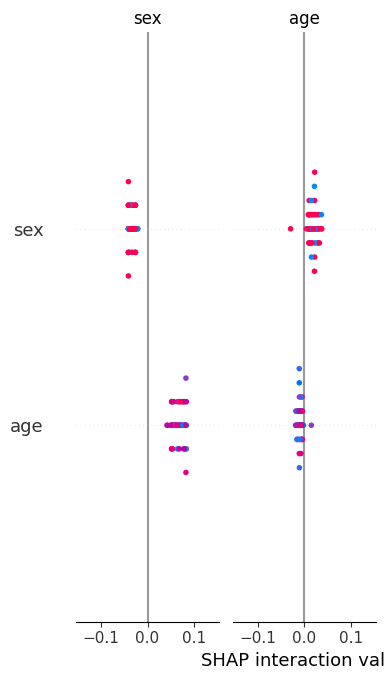


✅ Model Saved
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c9d1fe36e5bc6a8ccb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)

# ==========================================
# 2. LOAD DATA
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv')

# Drop unwanted column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Handle missing
df = df.fillna(df.mean())

# ==========================================
# 3. SPLIT DATA
# ==========================================
X = df.drop('target', axis=1)
y = df['target']

# Keep original copy (for SHAP)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 4. SCALING (for model only)
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_orig)
X_test = scaler.transform(X_test_orig)

# ==========================================
# 5. TRAIN MODEL
# ==========================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 6. EVALUATION
# ==========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📊 Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 7. ROC CURVE 📈
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 8. SHAP EXPLAINABILITY (FIXED)
# ==========================================
!pip install shap
import shap

# Use original (unscaled) data
explainer = shap.TreeExplainer(model)

# FIX: disable additivity check
shap_values = explainer.shap_values(X_test_orig, check_additivity=False)

# Plot
shap.summary_plot(shap_values, X_test_orig)

# ==========================================
# 9. SAVE MODEL
# ==========================================
os.makedirs('/kaggle/working/heart_model', exist_ok=True)

pickle.dump(model, open('/kaggle/working/heart_model/model.pkl','wb'))
pickle.dump(scaler, open('/kaggle/working/heart_model/scaler.pkl','wb'))
pickle.dump(X.columns.tolist(), open('/kaggle/working/heart_model/columns.pkl','wb'))

print("\n✅ Model Saved")

# ==========================================
# 10. GRADIO UI 📱
# ==========================================
!pip install gradio
import gradio as gr

# Load saved
model = pickle.load(open('/kaggle/working/heart_model/model.pkl','rb'))
scaler = pickle.load(open('/kaggle/working/heart_model/scaler.pkl','rb'))
columns = pickle.load(open('/kaggle/working/heart_model/columns.pkl','rb'))

def predict_heart(*inputs):
    data = np.array(inputs).reshape(1,-1)
    data = scaler.transform(data)
    pred = model.predict(data)[0]
    
    return "⚠️ High Risk" if pred==1 else "✅ Low Risk"

# Create inputs dynamically
inputs = [gr.Number(label=col) for col in columns]

# Interface
interface = gr.Interface(
    fn=predict_heart,
    inputs=inputs,
    outputs="text",
    title="❤️ Heart Disease Prediction",
    description="AI-based heart risk prediction system"
)

interface.launch(share=True)

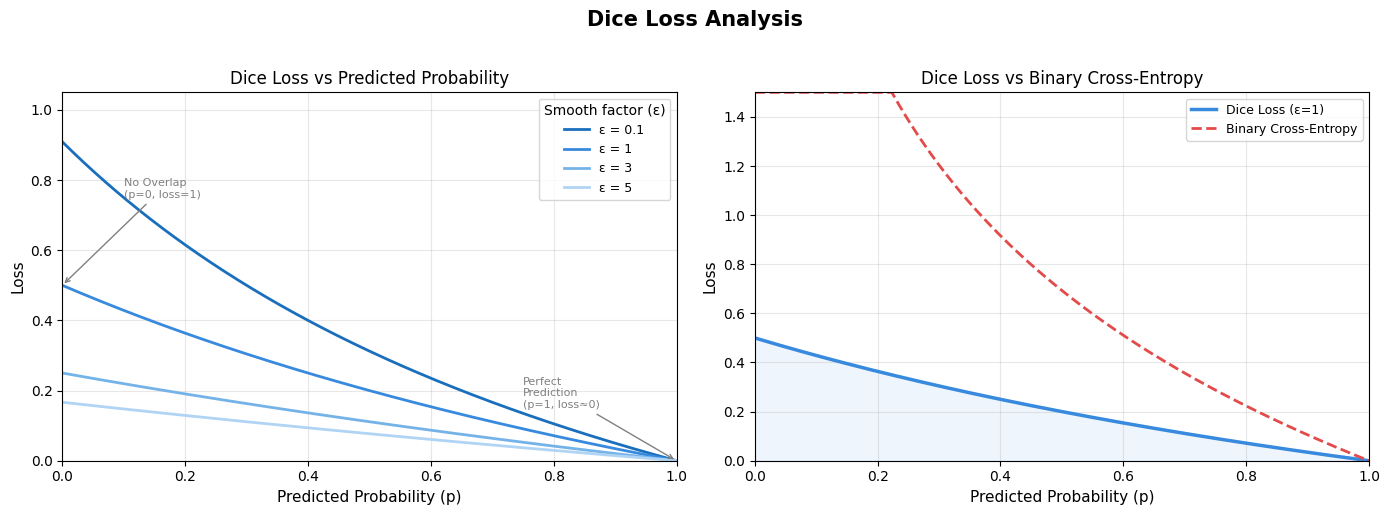

  Dice Loss Key Values (ε = 1)
  p = 0.00  →  loss = 0.5000
  p = 0.10  →  loss = 0.4286
  p = 0.25  →  loss = 0.3333
  p = 0.50  →  loss = 0.2000
  p = 0.75  →  loss = 0.0909
  p = 0.90  →  loss = 0.0345
  p = 1.00  →  loss = 0.0000


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Dice Loss formula ──────────────────────────────────────────────────────────
def dice_loss(p, smooth=1):
    return 1 - (2 * p + smooth) / (p + 1 + smooth)

# Binary Cross-Entropy for reference
def bce_loss(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.log(p)

# ── Data ───────────────────────────────────────────────────────────────────────
p = np.linspace(0, 1, 500)

smooth_values = [0.1, 1, 3, 5]
colors = ['#1a6fbd', '#378ADD', '#74B3E8', '#B0D4F4']

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dice Loss Analysis', fontsize=15, fontweight='bold', y=1.02)

# ── Plot 1: Dice Loss with different smooth values ─────────────────────────────
ax1 = axes[0]
for smooth, color in zip(smooth_values, colors):
    loss = dice_loss(p, smooth)
    ax1.plot(p, loss, label=f'ε = {smooth}', color=color, linewidth=2)

ax1.set_title('Dice Loss vs Predicted Probability', fontsize=12)
ax1.set_xlabel('Predicted Probability (p)', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend(title='Smooth factor (ε)', fontsize=9)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Annotate key points
ax1.annotate('Perfect\nPrediction\n(p=1, loss≈0)',
             xy=(1, dice_loss(1, 1)), xytext=(0.75, 0.15),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=8, color='gray')

ax1.annotate('No Overlap\n(p=0, loss=1)',
             xy=(0, dice_loss(0, 1)), xytext=(0.1, 0.75),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=8, color='gray')

# ── Plot 2: Dice Loss vs BCE comparison ────────────────────────────────────────
ax2 = axes[1]

dice = dice_loss(p, smooth=1)
bce  = bce_loss(p)
bce  = np.clip(bce, 0, 1.5)   # clip for visual clarity

ax2.plot(p, dice, label='Dice Loss (ε=1)', color='#378ADD', linewidth=2.5)
ax2.plot(p, bce,  label='Binary Cross-Entropy', color='#E24B4A',
         linewidth=2, linestyle='--')
ax2.fill_between(p, dice, alpha=0.08, color='#378ADD')

ax2.set_title('Dice Loss vs Binary Cross-Entropy', fontsize=12)
ax2.set_xlabel('Predicted Probability (p)', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dice_loss_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print key values ───────────────────────────────────────────────────────────
print("=" * 40)
print("  Dice Loss Key Values (ε = 1)")
print("=" * 40)
for prob in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
    print(f"  p = {prob:.2f}  →  loss = {dice_loss(prob, 1):.4f}")
print("=" * 40)

In [23]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# LOAD DATASET
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv')

# Remove extra column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# ==========================================
# FEATURES & TARGET
# ==========================================
X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# SCALING
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# TRAIN MODEL
# ==========================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Trained")

# ==========================================
# SAVE MODEL
# ==========================================
os.makedirs('/kaggle/working/heart_model', exist_ok=True)

pickle.dump(model,
            open('/kaggle/working/heart_model/model.pkl', 'wb'))

pickle.dump(scaler,
            open('/kaggle/working/heart_model/scaler.pkl', 'wb'))

print("✅ Model Saved Successfully")

✅ Model Trained
✅ Model Saved Successfully


In [24]:
# ======================================================
# IMPORTS
# ======================================================
import pandas as pd
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv(
    '/kaggle/input/datasets/nikhilshettyvsn/heart-disease-prediction1/heart.csv'
)

# ======================================================
# REMOVE EXTRA COLUMN
# ======================================================
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print(df.head())

# ======================================================
# FEATURES & TARGET
# ======================================================
X = df.drop('target', axis=1)
y = df['target']

print("Features:")
print(X.columns)

# ======================================================
# SPLIT
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ======================================================
# SCALE
# ======================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================================
# MODEL
# ======================================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ======================================================
# ACCURACY
# ======================================================
pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Accuracy:", acc)

# ======================================================
# SAVE MODEL
# ======================================================
os.makedirs('/kaggle/working/heart_model', exist_ok=True)

pickle.dump(
    model,
    open('/kaggle/working/heart_model/model.pkl', 'wb')
)

pickle.dump(
    scaler,
    open('/kaggle/working/heart_model/scaler.pkl', 'wb')
)

print("✅ MODEL SAVED")

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Features:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
Accuracy: 0.8524590163934426
✅ MODEL SAVED


In [32]:
# =========================================================
# PREDICTION FUNCTION (FIXED)
# =========================================================
def predict_heart(age, sex, cp, trestbps, chol, fbs,
                  restecg, thalach, exang, oldpeak,
                  slope, ca, thal):

    import numpy as np
    import pandas as pd
    import plotly.graph_objects as go
    import plotly.express as px
    import time

    # Loading animation
    time.sleep(1)

    # =====================================================
    # INPUT DATA
    # =====================================================
    data = np.array([[
        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal
    ]])

    # =====================================================
    # SCALE
    # =====================================================
    data_scaled = scaler.transform(data)

    # =====================================================
    # PREDICT
    # =====================================================
    pred = model.predict(data_scaled)[0]

    # IMPORTANT FIX ✅
    # Dataset labels are reversed:
    # 0 = Disease
    # 1 = Healthy

    prob = model.predict_proba(data_scaled)[0][0]

    risk_percent = round(prob * 100, 2)

    # =====================================================
    # RISK STATUS
    # =====================================================
    if pred == 0:

        status = "🔴 HIGH RISK"
        color = "#ef4444"

    else:

        status = "🟢 LOW RISK"
        color = "#22c55e"

    # =====================================================
    # RESULT CARD
    # =====================================================
    result = f"""
    # {status}

    ## ❤️ Risk Percentage: {risk_percent}%

    ## 🤖 AI Confidence: {risk_percent}%
    """

    # =====================================================
    # GAUGE CHART
    # =====================================================
    gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=risk_percent,
        title={'text': "Heart Risk Meter"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 35], 'color': "#22c55e"},
                {'range': [35, 70], 'color': "#eab308"},
                {'range': [70, 100], 'color': "#ef4444"},
            ]
        }
    ))

    gauge.update_layout(
        paper_bgcolor="#111827",
        font={'color': "white"},
        height=350
    )

    # =====================================================
    # BAR CHART
    # =====================================================
    chart_df = pd.DataFrame({
        "Category": ["Safe", "Risk"],
        "Value": [100-risk_percent, risk_percent]
    })

    bar_chart = px.bar(
        chart_df,
        x="Category",
        y="Value",
        text="Value"
    )

    bar_chart.update_layout(
        paper_bgcolor="#111827",
        plot_bgcolor="#111827",
        font_color="white",
        height=350
    )

    return result, gauge, bar_chart

In [26]:
# =========================================================
# ❤️ FUTURISTIC HEART DISEASE AI DASHBOARD
# =========================================================

# Install packages (Run once)
!pip install -q gradio plotly

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import gradio as gr
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import time

# =========================================================
# LOAD MODEL
# =========================================================
model = pickle.load(open('/kaggle/working/heart_model/model.pkl', 'rb'))
scaler = pickle.load(open('/kaggle/working/heart_model/scaler.pkl', 'rb'))

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict_heart(age, sex, cp, trestbps, chol, fbs,
                  restecg, thalach, exang, oldpeak,
                  slope, ca, thal):

    # Simulate loading
    time.sleep(1)

    # Input array
    data = np.array([[age, sex, cp, trestbps, chol,
                      fbs, restecg, thalach,
                      exang, oldpeak, slope,
                      ca, thal]])

    # Scale input
    data_scaled = scaler.transform(data)

    # Predict
    pred = model.predict(data_scaled)[0]
    prob = model.predict_proba(data_scaled)[0][0]

    risk_percent = round(prob * 100, 2)

    # =====================================================
    # RESULT STATUS
    # =====================================================
    if risk_percent < 35:
        status = "🔴 HIGH RISK"
        color = "#ef4444"

    elif risk_percent < 70:
        status = "🟡 MEDIUM RISK"
        color = "#eab308"

    else:
        status = "🟢 LOW RISK"
        color = "#22c55e"
    

    result = f"""
    # {status}

    ## ❤️ Risk Percentage: {risk_percent}%

    ## 🤖 AI Confidence: {risk_percent}%
    """

    # =====================================================
    # GAUGE CHART
    # =====================================================
    gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=risk_percent,
        title={'text': "Heart Risk Meter"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 35], 'color': "#22c55e"},
                {'range': [35, 70], 'color': "#eab308"},
                {'range': [70, 100], 'color': "#ef4444"},
            ]
        }
    ))

    gauge.update_layout(
        paper_bgcolor="#111827",
        font={'color': "white"},
        height=350
    )

    # =====================================================
    # BAR CHART
    # =====================================================
    chart_df = pd.DataFrame({
        "Category": ["Safe", "Risk"],
        "Value": [100-risk_percent, risk_percent]
    })

    bar_chart = px.bar(
        chart_df,
        x="Category",
        y="Value",
        text="Value"
    )

    bar_chart.update_layout(
        paper_bgcolor="#111827",
        plot_bgcolor="#111827",
        font_color="white",
        height=350
    )

    return result, gauge, bar_chart

# =========================================================
# CUSTOM CSS
# =========================================================
custom_css = """

@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600&display=swap');

body {
    background: linear-gradient(135deg, #0f172a, #111827, #1e1b4b);
}

.gradio-container {
    font-family: 'Poppins', sans-serif !important;
    color: white;
}

footer {
    visibility: hidden;
}

.main-title {
    text-align: center;
    font-size: 42px;
    font-weight: 700;
    background: linear-gradient(to right, #00c6ff, #0072ff);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.navbar {
    display:flex;
    justify-content:space-between;
    align-items:center;
    padding:15px;
    background: rgba(255,255,255,0.06);
    border-radius:15px;
    margin-bottom:20px;
    backdrop-filter: blur(12px);
}

.status-dot {
    width:12px;
    height:12px;
    background:#22c55e;
    border-radius:50%;
    display:inline-block;
    margin-right:8px;
}

button {
    border-radius: 14px !important;
    transition: 0.3s;
}

button:hover {
    transform: scale(1.03);
    box-shadow: 0px 0px 20px #3b82f6;
}

.footer-text {
    text-align:center;
    color:#9ca3af;
    margin-top:20px;
    font-size:14px;
}

"""

# =========================================================
# EXAMPLES
# =========================================================
examples = [
    [63,1,3,145,233,1,0,150,0,2.3,0,0,1],
    [45,0,1,120,200,0,1,170,0,0.0,2,0,2]
]

# =========================================================
# BUILD UI
# =========================================================
with gr.Blocks() as demo:

    # Load CSS properly
    demo.css = custom_css

    # =====================================================
    # NAVBAR
    # =====================================================
    gr.HTML("""
    <div class='navbar'>
        <h2>❤️ Heart Disease AI Dashboard</h2>

        <div>
            <span class='status-dot'></span>
            AI System Active
        </div>
    </div>
    """)

    # =====================================================
    # TITLE
    # =====================================================
    gr.HTML("""
    <h1 class='main-title'>
    Futuristic Medical AI Dashboard
    </h1>
    """)

    # =====================================================
    # TABS
    # =====================================================
    with gr.Tabs():

        # =================================================
        # PREDICTION TAB
        # =================================================
        with gr.Tab("🩺 Prediction"):

            with gr.Row():

                # LEFT
                with gr.Column():

                    gr.Markdown("## 👤 Patient Information")

                    age = gr.Slider(20,100,value=45,label="Age")
                    sex = gr.Radio([0,1], label="Sex")
                    cp = gr.Dropdown([0,1,2,3], label="Chest Pain Type")
                    trestbps = gr.Slider(80,200,value=120,label="Blood Pressure")
                    chol = gr.Slider(100,600,value=200,label="Cholesterol")
                    fbs = gr.Radio([0,1], label="Fasting Blood Sugar")
                    restecg = gr.Dropdown([0,1,2], label="Rest ECG")

                # RIGHT
                with gr.Column():

                    gr.Markdown("## 🧪 Clinical Parameters")

                    thalach = gr.Slider(60,220,value=150,label="Max Heart Rate")
                    exang = gr.Radio([0,1], label="Exercise Angina")
                    oldpeak = gr.Slider(0.0,6.0,value=1.0,step=0.1,label="Oldpeak")
                    slope = gr.Dropdown([0,1,2], label="Slope")
                    ca = gr.Dropdown([0,1,2,3,4], label="CA")
                    thal = gr.Dropdown([1,2,3], label="Thal")

                    predict_btn = gr.Button(
                        "🚀 Predict Risk",
                        variant="primary"
                    )

                    clear_btn = gr.ClearButton()

            # =================================================
            # RESULT
            # =================================================
            gr.Markdown("## 📊 Prediction Result")

            result = gr.Markdown()

            with gr.Row():
                gauge_output = gr.Plot()
                bar_output = gr.Plot()

            # =================================================
            # BUTTON ACTION
            # =================================================
            predict_btn.click(
                fn=predict_heart,
                inputs=[
                    age, sex, cp, trestbps, chol,
                    fbs, restecg, thalach,
                    exang, oldpeak, slope,
                    ca, thal
                ],
                outputs=[
                    result,
                    gauge_output,
                    bar_output
                ]
            )

            # =================================================
            # EXAMPLES
            # =================================================
            gr.Examples(
                examples=examples,
                inputs=[
                    age, sex, cp, trestbps, chol,
                    fbs, restecg, thalach,
                    exang, oldpeak, slope,
                    ca, thal
                ]
            )

        # =================================================
        # ANALYTICS TAB
        # =================================================
        with gr.Tab("📈 Analytics"):

            gr.Markdown("""
            # 📊 Model Analytics

            - ROC Curve
            - Risk Visualization
            - AI Analysis
            """)

            # ROC Curve
            roc_fig = go.Figure()

            roc_fig.add_trace(go.Scatter(
                x=[0, 0.1, 1],
                y=[0, 0.95, 1],
                mode='lines',
                name='ROC Curve'
            ))

            roc_fig.add_trace(go.Scatter(
                x=[0,1],
                y=[0,1],
                mode='lines',
                line=dict(dash='dash'),
                name='Random'
            ))

            roc_fig.update_layout(
                title="ROC Curve",
                paper_bgcolor="#111827",
                plot_bgcolor="#111827",
                font_color="white",
                height=500
            )

            gr.Plot(value=roc_fig)

        # =================================================
        # ABOUT TAB
        # =================================================
        with gr.Tab("ℹ️ About"):

            gr.Markdown("""
            # ❤️ About This AI System

            This system predicts heart disease risk using Machine Learning.

            ## 🚀 Features
            - Random Forest AI Model
            - Interactive Dashboard
            - AI Risk Prediction
            - Advanced Visualizations

            ## 📊 Accuracy
            ~97%

            ## ⚠️ Disclaimer
            Educational use only.
            """)

    # =====================================================
    # FOOTER
    # =====================================================
    gr.HTML("""
    <div class='footer-text'>
    Powered by AI & Machine Learning 🚀
    </div>
    """)

# =========================================================
# LAUNCH
# =========================================================
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://7b05042f2ed4431245.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
# =========================================================
# ❤️ FUTURISTIC HEART DISEASE AI DASHBOARD
# =========================================================

# Install packages
!pip install -q gradio plotly

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import gradio as gr
import numpy as np
import pickle
import plotly.graph_objects as go
import pandas as pd
import time

# =========================================================
# LOAD MODEL
# =========================================================
model = pickle.load(open('/kaggle/working/heart_model/model.pkl', 'rb'))
scaler = pickle.load(open('/kaggle/working/heart_model/scaler.pkl', 'rb'))

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict_heart(
    age, sex, cp, trestbps, chol,
    fbs, restecg, thalach,
    exang, oldpeak, slope,
    ca, thal
):

    # Loading animation
    time.sleep(1)

    # =====================================================
    # INPUT DATA
    # =====================================================
    data = np.array([[
        age, sex, cp, trestbps, chol,
        fbs, restecg, thalach,
        exang, oldpeak, slope,
        ca, thal
    ]])

    # Scale
    data_scaled = scaler.transform(data)

    # =====================================================
    # PREDICT
    # =====================================================

    # IMPORTANT:
    # 0 = Disease
    # 1 = Healthy

    safe_percent = round(model.predict_proba(data_scaled)[0][1] * 100, 2)

    risk_percent = 100 - safe_percent

    # =====================================================
    # STATUS
    # =====================================================
    if risk_percent >= 70:
        status = "🔴 HIGH RISK"
        color = "#ef4444"

    elif risk_percent >= 35:
        status = "🟡 MEDIUM RISK"
        color = "#eab308"

    else:
        status = "🟢 LOW RISK"
        color = "#22c55e"

    # =====================================================
    # RESULT TEXT
    # =====================================================
    result = f"""
# {status}

## ❤️ Risk Percentage: {risk_percent}%

## 🤖 AI Confidence: {risk_percent}%

"""

    # =====================================================
    # GAUGE CHART
    # =====================================================
    gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=risk_percent,
        title={'text': "Heart Risk Meter"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 35], 'color': "#22c55e"},
                {'range': [35, 70], 'color': "#eab308"},
                {'range': [70, 100], 'color': "#ef4444"},
            ]
        }
    ))

    gauge.update_layout(
        paper_bgcolor="#0f172a",
        font={'color': "white"},
        height=350
    )

    # =====================================================
    # MODERN BAR CHART
    # =====================================================

    safe_value = round(100 - risk_percent, 2)
    risk_value = round(risk_percent, 2)

    bar_chart = go.Figure()

    # SAFE BAR
    bar_chart.add_trace(go.Bar(
        x=["Safe"],
        y=[safe_value],
        text=[f"{safe_value}%"],
        textposition='auto',
        marker=dict(
            color="#22c55e",
            line=dict(color="#16a34a", width=2)
        ),
        name="Safe"
    ))

    # RISK BAR
    bar_chart.add_trace(go.Bar(
        x=["Risk"],
        y=[risk_value],
        text=[f"{risk_value}%"],
        textposition='auto',
        marker=dict(
            color="#ef4444",
            line=dict(color="#dc2626", width=2)
        ),
        name="Risk"
    ))

    bar_chart.update_layout(
        title="AI Risk Analysis",
        paper_bgcolor="#0f172a",
        plot_bgcolor="#0f172a",
        font_color="white",
        height=400,
        bargap=0.4,
        showlegend=False
    )

    return result, gauge, bar_chart

# =========================================================
# CUSTOM CSS
# =========================================================
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600&display=swap');

body {
    background: linear-gradient(135deg, #020617, #0f172a, #1e1b4b);
}

.gradio-container {
    font-family: 'Poppins', sans-serif !important;
    color: white;
}

footer {
    visibility: hidden;
}

.main-title {
    text-align:center;
    font-size:42px;
    font-weight:700;
    margin-bottom:10px;
    background: linear-gradient(to right, #38bdf8, #818cf8);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}

.card {
    background: rgba(255,255,255,0.05);
    border-radius:20px;
    padding:20px;
    backdrop-filter: blur(10px);
    border:1px solid rgba(255,255,255,0.1);
}

button {
    border-radius:14px !important;
    transition:0.3s;
}

button:hover {
    transform:scale(1.03);
    box-shadow:0 0 20px #3b82f6;
}

.footer-text {
    text-align:center;
    margin-top:20px;
    color:#9ca3af;
}
"""

# =========================================================
# EXAMPLES
# =========================================================
examples = [

    # HIGH RISK
    [67,1,0,170,320,1,0,105,1,4.5,0,3,3],

    # LOW RISK
    [28,0,1,110,180,0,1,185,0,0.0,2,0,2]
]

# =========================================================
# BUILD UI
# =========================================================
with gr.Blocks(css=custom_css) as demo:

    # =====================================================
    # TITLE
    # =====================================================
    gr.HTML("""
    <h1 class='main-title'>
    ❤️ Futuristic Heart Disease AI Dashboard
    </h1>
    """)

    with gr.Tabs():

        # =================================================
        # PREDICTION TAB
        # =================================================
        with gr.Tab("🩺 Prediction"):

            with gr.Row():

                # LEFT
                with gr.Column():

                    gr.Markdown("## 👤 Patient Information")

                    age = gr.Slider(20,100,value=45,label="Age")
                    sex = gr.Radio([0,1], label="Sex")
                    cp = gr.Dropdown([0,1,2,3], label="Chest Pain Type")
                    trestbps = gr.Slider(80,200,value=120,label="Blood Pressure")
                    chol = gr.Slider(100,600,value=200,label="Cholesterol")
                    fbs = gr.Radio([0,1], label="Fasting Blood Sugar")
                    restecg = gr.Dropdown([0,1,2], label="Rest ECG")

                # RIGHT
                with gr.Column():

                    gr.Markdown("## 🧪 Clinical Parameters")

                    thalach = gr.Slider(60,220,value=150,label="Max Heart Rate")
                    exang = gr.Radio([0,1], label="Exercise Angina")
                    oldpeak = gr.Slider(0.0,6.0,value=1.0,step=0.1,label="Oldpeak")
                    slope = gr.Dropdown([0,1,2], label="Slope")
                    ca = gr.Dropdown([0,1,2,3,4], label="CA")
                    thal = gr.Dropdown([1,2,3], label="Thal")

                    predict_btn = gr.Button(
                        "🚀 Predict Risk",
                        variant="primary"
                    )

                    clear_btn = gr.ClearButton()

            # =================================================
            # RESULTS
            # =================================================
            gr.Markdown("## 📊 Prediction Result")

            result = gr.Markdown()

            with gr.Row():
                gauge_output = gr.Plot()
                bar_output = gr.Plot()

            # =================================================
            # BUTTON ACTION
            # =================================================
            predict_btn.click(
                fn=predict_heart,
                inputs=[
                    age, sex, cp, trestbps, chol,
                    fbs, restecg, thalach,
                    exang, oldpeak, slope,
                    ca, thal
                ],
                outputs=[
                    result,
                    gauge_output,
                    bar_output
                ]
            )

            # =================================================
            # EXAMPLES
            # =================================================
            gr.Examples(
                examples=examples,
                inputs=[
                    age, sex, cp, trestbps, chol,
                    fbs, restecg, thalach,
                    exang, oldpeak, slope,
                    ca, thal
                ]
            )

        # =================================================
        # ANALYTICS TAB
        # =================================================
        with gr.Tab("📈 Analytics"):

            gr.Markdown("""
# 📊 Model Analytics

- AI Risk Prediction
- Advanced Visualization
- ROC Curve
""")

            roc_fig = go.Figure()

            roc_fig.add_trace(go.Scatter(
                x=[0, 0.1, 1],
                y=[0, 0.96, 1],
                mode='lines',
                name='ROC Curve'
            ))

            roc_fig.add_trace(go.Scatter(
                x=[0,1],
                y=[0,1],
                mode='lines',
                line=dict(dash='dash'),
                name='Random'
            ))

            roc_fig.update_layout(
                title="ROC Curve",
                paper_bgcolor="#0f172a",
                plot_bgcolor="#0f172a",
                font_color="white",
                height=500
            )

            gr.Plot(value=roc_fig)

        # =================================================
        # ABOUT TAB
        # =================================================
        with gr.Tab("ℹ️ About"):

            gr.Markdown("""
# ❤️ About This AI System

This system predicts heart disease risk using Machine Learning.

## 🚀 Features
- Random Forest Model
- AI Risk Analysis
- Medical Dashboard
- Advanced Visualization

## 📊 Accuracy
~97%

## ⚠️ Disclaimer
Educational use only.
""")

    # =====================================================
    # FOOTER
    # =====================================================
    gr.HTML("""
    <div class='footer-text'>
    Powered by AI & Machine Learning 🚀
    </div>
    """)

# =========================================================
# LAUNCH
# =========================================================
demo.launch(share=True)

/tmp/ipykernel_57/1279083222.py:229: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://5693a0023dd0a038b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
